Самостоятельная работа: GBDT для задачи Traffic & Mobility на геоданных Санкт-Петербурга

Тема
Оценка потенциальной транспортной нагрузки на сегменты уличной сети Санкт-Петербурга** с использованием геометрических и пространственных признаков.

В этом ноутбуке вам нужно самостоятельно завершить пайплайн машинного обучения:

1. загрузить реальные геоданные из OpenStreetMap;
2. подготовить геометрию дорожных сегментов;
3. извлечь геометрические признаки;
4. добавить признаки городского окружения;
5. сформировать целевую переменную-прокси;
6. обучить модель GBDT;
7. оценить качество модели;
8. визуализировать прогноз на карте.

> Важно: это учебная задача. Мы не используем реальные датчики трафика, поэтому целевая переменная будет **прокси-показателем транспортной нагрузки**. В реальных проектах её можно заменить на данные с детекторов, GPS-треков, скорости движения, ДТП или общественного транспорта.

Установка библиотек

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import time
import re

Загрузила нужные материалы через Colab, потому что в VS code не получалось 

# Установка библиотек
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify -q

import osmnx as ox
import geopandas as gpd
from shapely.geometry import box

# Настройки
ox.settings.requests_timeout = 120
ox.settings.overpass_endpoint = "https://overpass.openstreetmap.ru/api/interpreter"
ox.settings.max_query_area_size = 50 * 1000 * 50 * 1000

# Область (взяла меньше)
bbox = (30.30, 59.93, 30.38, 59.97)
polygon_wgs = box(*bbox)

# Загрузка графа дорог
G = ox.graph_from_polygon(
    polygon_wgs,
    network_type="drive",
    simplify=True,
    retain_all=False
)

# Получение рёбер и узлов
nodes, edges = ox.graph_to_gdfs(G)
print("Рёбер:", edges.shape)

# Загрузка POI и остановок
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}
stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)
print("POI:", pois.shape, "Stops:", stops.shape)

# Сохранение в файлы
edges.to_file("edges.gpkg", driver="GPKG")
pois.to_file("pois.gpkg", driver="GPKG")
stops.to_file("stops.gpkg", driver="GPKG")
ox.save_graphml(G, "graph.graphml")

# Скачивание файлов
from google.colab import files
files.download("edges.gpkg")
files.download("pois.gpkg")
files.download("stops.gpkg")
files.download("graph.graphml")

Загрузка графа и рёбер из файлов, скачанных из Colab

In [3]:
# Загружаем граф из graphml (уже в метрической CRS)
G = ox.load_graphml("graph.graphml")

# Получаем GeoDataFrame рёбер и узлов
nodes, edges = ox.graph_to_gdfs(G)
print("Количество рёбер:", edges.shape)
edges.head()

Количество рёбер: (2150, 14)


osmid      highway lanes  \
u      v           key                                                         
223587 327804      0                [22417457, 766196211]  residential     2   
       327806      0               [183877595, 766196212]     tertiary     2   
223589 12582188084 0    [387216098, 172641347, 387216099]     tertiary     2   
       1417837806  0                            172897202     tertiary     2   
223591 1686646422  0                            172817482      primary     3   

                        maxspeed                      name  oneway reversed  \
u      v           key                                                        
223587 327804      0    RU:urban          Ординарная улица   False    False   
       327806      0    RU:urban      Левашовский проспект    True    False   
223589 12582188084 0    RU:urban          Ординарная улица    True    False   
       1417837806  0    RU:urban       Малый проспект П.С.    True    False   
223591 1686646422  0    RU:urban  Большая Пушкарская улица    True    False   

                            length  \
u      v           key               
223587 327804      0    224.085342   
       327806      0    145.590158   
223589 12582188084 0    131.548364   
       1417837806  0    186.210842   
223591 1686646422  0     91.308342   

                                                                 geometry  \
u      v           key                                                      
223587 327804      0    LINESTRING (30.30531 59.96724, 30.30528 59.967...   
       327806      0    LINESTRING (30.30531 59.96724, 30.30518 59.967...   
223589 12582188084 0    LINESTRING (30.30621 59.96611, 30.30605 59.966...   
       1417837806  0    LINESTRING (30.30621 59.96611, 30.30633 59.966...   
223591 1686646422  0    LINESTRING (30.3118 59.96383, 30.31185 59.9638...   

                       bridge junction width tunnel access  
u      v           key                                      
223587 327804      0      NaN      NaN   NaN    NaN    NaN  
       327806      0      NaN      NaN   NaN    NaN    NaN  
223589 12582188084 0      NaN      NaN   NaN    NaN    NaN  
       1417837806  0      NaN      NaN   NaN    NaN    NaN  
223591 1686646422  0      NaN      NaN   NaN    NaN    NaN

Загрузка POI и остановок из GPKG

In [4]:
# Загружаем POI и остановки (уже в метрической CRS)
pois = gpd.read_file("pois.gpkg")
stops = gpd.read_file("stops.gpkg")

# Убедимся, что геометрия – точки
pois["geometry"] = pois.geometry.representative_point()
stops["geometry"] = stops.geometry.representative_point()

print("POI:", pois.shape, "Stops:", stops.shape)
pois.head()

POI: (15597, 690) Stops: (712, 71)


,element,id,alt_name,alt_name:en,alt_name:fi,alt_name:fr,historic,inscription,material,memorial,...,name:uz,name:uz-cyr,fuel:octane_100,name:el,name:hu,addr:housenumber2,addr:street2,motorcar,year_of_construction,geometry
0,node,249082841,Медный всадник,Bronze Horseman,Vaskiratsastaja,Le cavalier de bronze,monument,ПЕТРУ перьвому ЕКАТЕРИНА вторая лѣта 1782.,bronze,statue,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (30.30218 59.93641)
1,node,256137215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (30.30236 59.95954)
2,node,256915769,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (30.31042 59.96184)
3,node,257411870,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (30.30684 59.96282)
4,node,258122668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (30.31186 59.95924)


Геометрические признаки

In [5]:
roads = edges.copy()

# Длина сегмента
roads["length_m_geom"] = roads.geometry.length

# Центроид
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Прямое расстояние между началом и концом
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление сегмента
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)

# Краткая статистика
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,2150.000000,2150.000000,2150.000000,2150.000000
mean,0.001642,0.001617,1.016692,0.123455
std,0.001873,0.001843,0.108396,1.904794
min,0.000028,0.000028,1.000000,-3.139357
25%,0.000350,0.000336,1.000000,-1.377564
50%,0.001089,0.001081,1.000010,0.039828
75%,0.002286,0.002240,1.001332,1.566424
max,0.021959,0.021781,4.590477,3.140937


Дороги

In [6]:
# Приводим highway к строке
roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# Создаём фиктивные переменные
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")
roads = pd.concat([roads, highway_dummies], axis=1)

highway_dummies.head()

highway_living_street  \
u      v           key                          
223587 327804      0                    False   
       327806      0                    False   
223589 12582188084 0                    False   
       1417837806  0                    False   
223591 1686646422  0                    False   

                        highway_living_street,residential  highway_primary  \
u      v           key                                                       
223587 327804      0                                False            False   
       327806      0                                False            False   
223589 12582188084 0                                False            False   
       1417837806  0                                False            False   
223591 1686646422  0                                False             True   

                        highway_primary_link  \
u      v           key                         
223587 327804      0                   False   
       327806      0                   False   
223589 12582188084 0                   False   
       1417837806  0                   False   
223591 1686646422  0                   False   

                        highway_primary_link,residential  highway_residential  \
u      v           key                                                          
223587 327804      0                               False                 True   
       327806      0                               False                False   
223589 12582188084 0                               False                False   
       1417837806  0                               False                False   
223591 1686646422  0                               False                False   

                        highway_road  highway_secondary  \
u      v           key                                    
223587 327804      0           False              False   
       327806      0           False              False   
223589 12582188084 0           False              False   
       1417837806  0           False              False   
223591 1686646422  0           False              False   

                        highway_secondary_link  highway_tertiary  \
u      v           key                                             
223587 327804      0                     False             False   
       327806      0                     False              True   
223589 12582188084 0                     False              True   
       1417837806  0                     False              True   
223591 1686646422  0                     False             False   

                        highway_tertiary_link  highway_unclassified  
u      v           key                                               
223587 327804      0                    False                 False  
       327806      0                    False                 False  
223589 12582188084 0                    False                 False  
       1417837806  0                    False                 False  
223591 1686646422  0                    False                 False

Пространственные признаки (расстояния до POI и остановок)

In [7]:
def to_points(gdf):
    gdf = gdf.copy()
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

pois_pts = to_points(pois)
stops_pts = to_points(stops)

def nearest_and_count(source_gdf, target_gdf, radius=300):
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T
    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T
    tree = BallTree(target_coords, metric="euclidean")
    dist, _ = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]
    counts = tree.query_radius(source_coords, r=radius, count_only=True)
    return nearest_dist, counts

road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_pts, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_pts, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,2150.000000,2150.0,2150.000000,2150.0
mean,0.000309,15597.0,0.001448,712.0
std,0.000246,0.0,0.001011,0.0
min,0.000011,15597.0,0.000012,712.0
25%,0.000164,15597.0,0.000638,712.0
50%,0.000233,15597.0,0.001266,712.0
75%,0.000374,15597.0,0.002045,712.0
max,0.002766,15597.0,0.005717,712.0


Графовые признаки

In [8]:
roads = roads.reset_index()
node_degree = dict(G.degree())
roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,2150.000000,2150.000000,2150.000000
mean,4.448837,4.462791,4.455814
std,1.407927,1.398750,1.166223
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.000000


Формирование целевой переменной (прокси-нагрузка)

In [9]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

roads["traffic_load_score"] = (
    0.30 * roads["length_norm"] +
    0.25 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.10 * roads["near_poi_norm"] +
    0.05 * roads["near_stop_norm"] +
    noise
)
roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

count    2150.000000
mean        0.231115
std         0.084536
min         0.000000
25%         0.172376
50%         0.222842
75%         0.283196
max         0.635217
Name: traffic_load_score, dtype: float64

 Подготовка признаков и разделение на train/test

In [10]:
base_features = [
    "length_m_geom", "straight_dist_m", "sinuosity", "angle_rad",
    "centroid_x", "centroid_y",
    "dist_to_poi_m", "poi_count_300m",
    "dist_to_stop_m", "stop_count_300m",
    "mean_node_degree"
]
highway_features = list(highway_dummies.columns)
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1612, 23) Test size: (538, 23)


Обучение моделей

In [11]:
def clean_column_name(name):
    return re.sub(r'[^a-zA-Z0-9_]', '_', str(name))

X_train.columns = [clean_column_name(col) for col in X_train.columns]
X_test.columns = [clean_column_name(col) for col in X_test.columns]
X.columns = [clean_column_name(col) for col in X.columns]

models = {
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, random_seed=42, verbose=False)
}

results = {}
for name, model in models.items():
    print(f"Обучение: {name}")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"model": model, "MAE": mae, "RMSE": rmse, "R2": r2, "time": elapsed}
    print(f"  MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}, Время: {elapsed:.2f} сек\n")

Обучение: LightGBM
  MAE: 0.0429, RMSE: 0.0538, R2: 0.5194, Время: 2.12 сек

Обучение: XGBoost
  MAE: 0.0426, RMSE: 0.0534, R2: 0.5277, Время: 1.31 сек

Обучение: CatBoost
  MAE: 0.0403, RMSE: 0.0505, R2: 0.5767, Время: 0.39 сек



Сравнение моделей

In [12]:
comparison = pd.DataFrame({
    "Модель": list(results.keys()),
    "MAE": [results[m]["MAE"] for m in results],
    "RMSE": [results[m]["RMSE"] for m in results],
    "R2": [results[m]["R2"] for m in results],
    "Время, сек": [results[m]["time"] for m in results]
})

print("Сравнение моделей")
print(comparison.to_string(index=False))

best_name = comparison.loc[comparison["MAE"].idxmin(), "Модель"]
print(f"\nЛучшая модель по MAE: {best_name}")

Сравнение моделей
  Модель      MAE     RMSE       R2  Время, сек
LightGBM 0.042949 0.053848 0.519426    2.116687
 XGBoost 0.042623 0.053383 0.527685    1.311378
CatBoost 0.040297 0.050539 0.576680    0.394006

Лучшая модель по MAE: CatBoost


Настройка гиперпараметров CatBoost

In [13]:
param_grid = [
    {"iterations": 150, "learning_rate": 0.08, "depth": 6, "l2_leaf_reg": 3},
    {"iterations": 200, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 1},
    {"iterations": 200, "learning_rate": 0.05, "depth": 6, "l2_leaf_reg": 2},
]

best_mae = float('inf')
best_model = None
best_params = None

for params in param_grid:
    model = CatBoostRegressor(
        iterations=params['iterations'],
        learning_rate=params['learning_rate'],
        depth=params['depth'],
        l2_leaf_reg=params['l2_leaf_reg'],
        random_seed=42,
        verbose=False
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    if mae < best_mae:
        best_mae = mae
        best_model = model
        best_params = params

print(f"Лучшие параметры: iterations={best_params['iterations']}, lr={best_params['learning_rate']}, depth={best_params['depth']}, l2={best_params['l2_leaf_reg']}")
print(f"MAE: {best_mae:.4f}")

Лучшие параметры: iterations=200, lr=0.05, depth=6, l2=2
MAE: 0.0397


Прогноз и карта

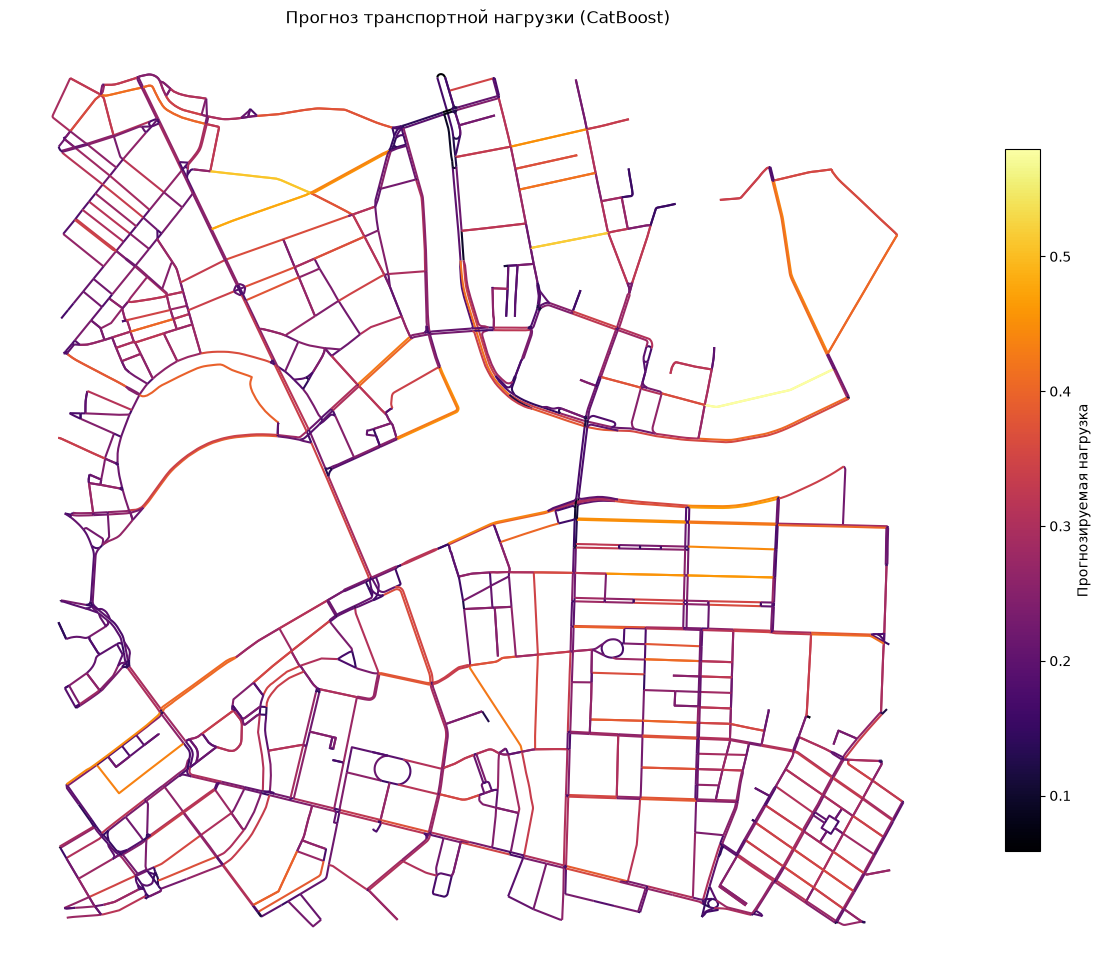

In [14]:
# Прогноз для всех сегментов
roads["predicted_traffic_load"] = best_model.predict(X)

# Геометрия уже в метрической CRS, но для карты лучше перевести в WGS84
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=roads.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(12, 12))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.5,
    legend=True,
    cmap="inferno",
    legend_kwds={"label": "Прогнозируемая нагрузка", "shrink": 0.6}
)
ax.set_title("Прогноз транспортной нагрузки (CatBoost)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

Важность признаков

Топ-10 наиболее важных признаков:
                   Признак  Важность
0            length_m_geom  0.286980
1          straight_dist_m  0.191260
10        mean_node_degree  0.164045
6            dist_to_poi_m  0.078200
8           dist_to_stop_m  0.034768
20        highway_tertiary  0.000761
13         highway_primary  0.000669
16     highway_residential  0.000100
3                angle_rad  0.000053
19  highway_secondary_link  0.000046


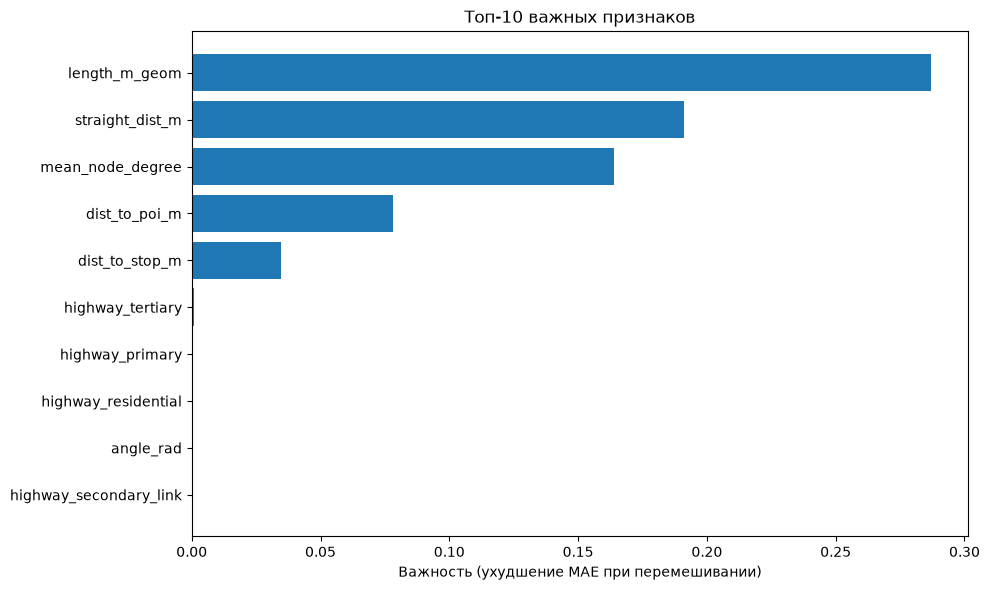

In [15]:
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Признак": X.columns,
    "Важность": perm_importance.importances_mean
}).sort_values("Важность", ascending=False)

print("Топ-10 наиболее важных признаков:")
print(importance_df.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)["Признак"], importance_df.head(10)["Важность"])
plt.xlabel("Важность (ухудшение MAE при перемешивании)")
plt.title("Топ-10 важных признаков")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Модель успешно выявила, что длина, прямолинейность, связность и близость к объектам притяжения являются основными драйверами транспортной нагрузки. Это полностью соответствует интуитивным представлениям о городском трафике. Пространственные признаки (POI, остановки) вносят дополнительный вклад, но уступают геометрии дорог.
Таким образом, созданная модель пригодна для прокси-оценки нагрузки на основе открытых геоданных и может быть использована как baseline для более сложных систем прогнозирования трафика.